In [5]:
import numpy as np
import pandas as pd
from scipy import sparse
import time
import os

os.chdir(os.getcwd())


X_train_cv = sparse.load_npz("X_train_cv.npz")
X_test_cv = sparse.load_npz("X_test_cv.npz")
X_train_tfidf = sparse.load_npz("X_train_tfidf.npz")
X_test_tfidf = sparse.load_npz("X_test_tfidf.npz")
X_train_chi2 = sparse.load_npz("X_train_chi2.npz")
X_test_chi2 = sparse.load_npz("X_test_chi2.npz")
X_train_svd = np.load("X_train_svd.npy")
X_test_svd = np.load("X_test_svd.npy")
X_train_pca = np.load("X_train_pca.npy")
X_test_pca = np.load("X_test_pca.npy")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Everything loaded!")

Everything loaded!


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
results=[]
def train_and_evaluate(X_train, X_test, name):
    models={
        "Logistic L1":LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
        "Logistic L2":LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000),
        "Linear SVM": LinearSVC(max_iter=1000)
    }
    for model_name,model in models.items():
        start_train=time.time()
        model.fit(X_train,y_train)
        end_train=time.time()
        start_infer=time.time()
        y_pred=model.predict(X_test)
        end_infer=time.time()
        f1=f1_score(y_test,y_pred)
        train_time=end_train-start_train
        infer_time = (end_infer - start_infer) / X_test.shape[0] * 1000
        results.append({
            "Vectorizer":name,
            "Model":model_name,
            "F1-score": round(f1,4),
            "Train Time (s)": round(train_time, 2),
            "Inference (ms)": round(infer_time, 4)
        })
        print(f"{name} + {model_name} → F1: {f1:.4f}, Train: {train_time:.2f}s")



In [7]:
train_and_evaluate(X_train_cv,    X_test_cv,    "Count Vectorizer")
train_and_evaluate(X_train_tfidf, X_test_tfidf, "TF-IDF")
train_and_evaluate(X_train_chi2,  X_test_chi2,  "Chi-Square")
train_and_evaluate(X_train_svd,   X_test_svd,   "SVD")
train_and_evaluate(X_train_pca,   X_test_pca,   "PCA GloVe")

c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Count Vectorizer + Logistic L1 → F1: 0.8534, Train: 0.73s


c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Count Vectorizer + Logistic L2 → F1: 0.8482, Train: 1.62s
Count Vectorizer + Linear SVM → F1: 0.8184, Train: 5.47s


c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

SVD + Logistic L1 → F1: 0.8777, Train: 6.26s


c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


SVD + Logistic L2 → F1: 0.8783, Train: 3.17s
SVD + Linear SVM → F1: 0.8765, Train: 2.38s
PCA GloVe + Logistic L1 → F1: 0.7851, Train: 0.12s


c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Deeptie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

PCA GloVe + Logistic L2 → F1: 0.7848, Train: 0.14s
PCA GloVe + Linear SVM → F1: 0.7852, Train: 0.17s


In [8]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv("results.csv", index=False)
print("Results saved!")

      Vectorizer       Model  F1-score  Train Time (s)  Inference (ms)
Count Vectorizer Logistic L1    0.8534            0.73          0.0011
Count Vectorizer Logistic L2    0.8482            1.62          0.0004
Count Vectorizer  Linear SVM    0.8184            5.47          0.0002
          TF-IDF Logistic L1    0.8787            0.30          0.0003
          TF-IDF Logistic L2    0.8797            0.32          0.0002
          TF-IDF  Linear SVM    0.8621            0.50          0.0002
      Chi-Square Logistic L1    0.8711            0.15          0.0002
      Chi-Square Logistic L2    0.8699            0.32          0.0002
      Chi-Square  Linear SVM    0.8687            0.39          0.0001
             SVD Logistic L1    0.8777            6.26          0.0036
             SVD Logistic L2    0.8783            3.17          0.0012
             SVD  Linear SVM    0.8765            2.38          0.0011
       PCA GloVe Logistic L1    0.7851            0.12          0.0002
      

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
new_results=[]
def trainNewModels(X_train,X_test,name):
    models = {
        "Naive Bayes": GaussianNB(),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "SVM RBF": SVC(kernel="rbf", random_state=42)
    }
    for model_name, model in models.items():
        start_train = time.time()
        model.fit(X_train, y_train)
        end_train = time.time()

        start_infer = time.time()
        y_pred = model.predict(X_test)
        end_infer = time.time()
        f1 = f1_score(y_test, y_pred)
        train_time = end_train - start_train
        infer_time = (end_infer - start_infer) / X_test.shape[0] * 1000
        new_results.append({
            "Vectorizer": name,
            "Model": model_name,
            "F1 Score": round(f1, 4),
            "Train Time (s)": round(train_time, 2),
            "Inference (ms)": round(infer_time, 4)
        })
        print(f"{name} + {model_name} → F1: {f1:.4f}, Train: {train_time:.2f}s")


In [10]:
trainNewModels(X_train_pca, X_test_pca, "PCA GloVe")

PCA GloVe + Naive Bayes → F1: 0.6939, Train: 0.03s
PCA GloVe + LDA → F1: 0.7850, Train: 0.10s
PCA GloVe + QDA → F1: 0.7358, Train: 0.22s
PCA GloVe + SVM RBF → F1: 0.8015, Train: 21.79s


In [11]:
new_results_df = pd.DataFrame(new_results)
print(new_results_df.to_string(index=False))
new_results_df.to_csv("new_results.csv", index=False)
print("Saved!")

Vectorizer       Model  F1 Score  Train Time (s)  Inference (ms)
 PCA GloVe Naive Bayes    0.6939            0.03          0.0008
 PCA GloVe         LDA    0.7850            0.10          0.0001
 PCA GloVe         QDA    0.7358            0.22          0.0007
 PCA GloVe     SVM RBF    0.8015           21.79          2.6664
Saved!


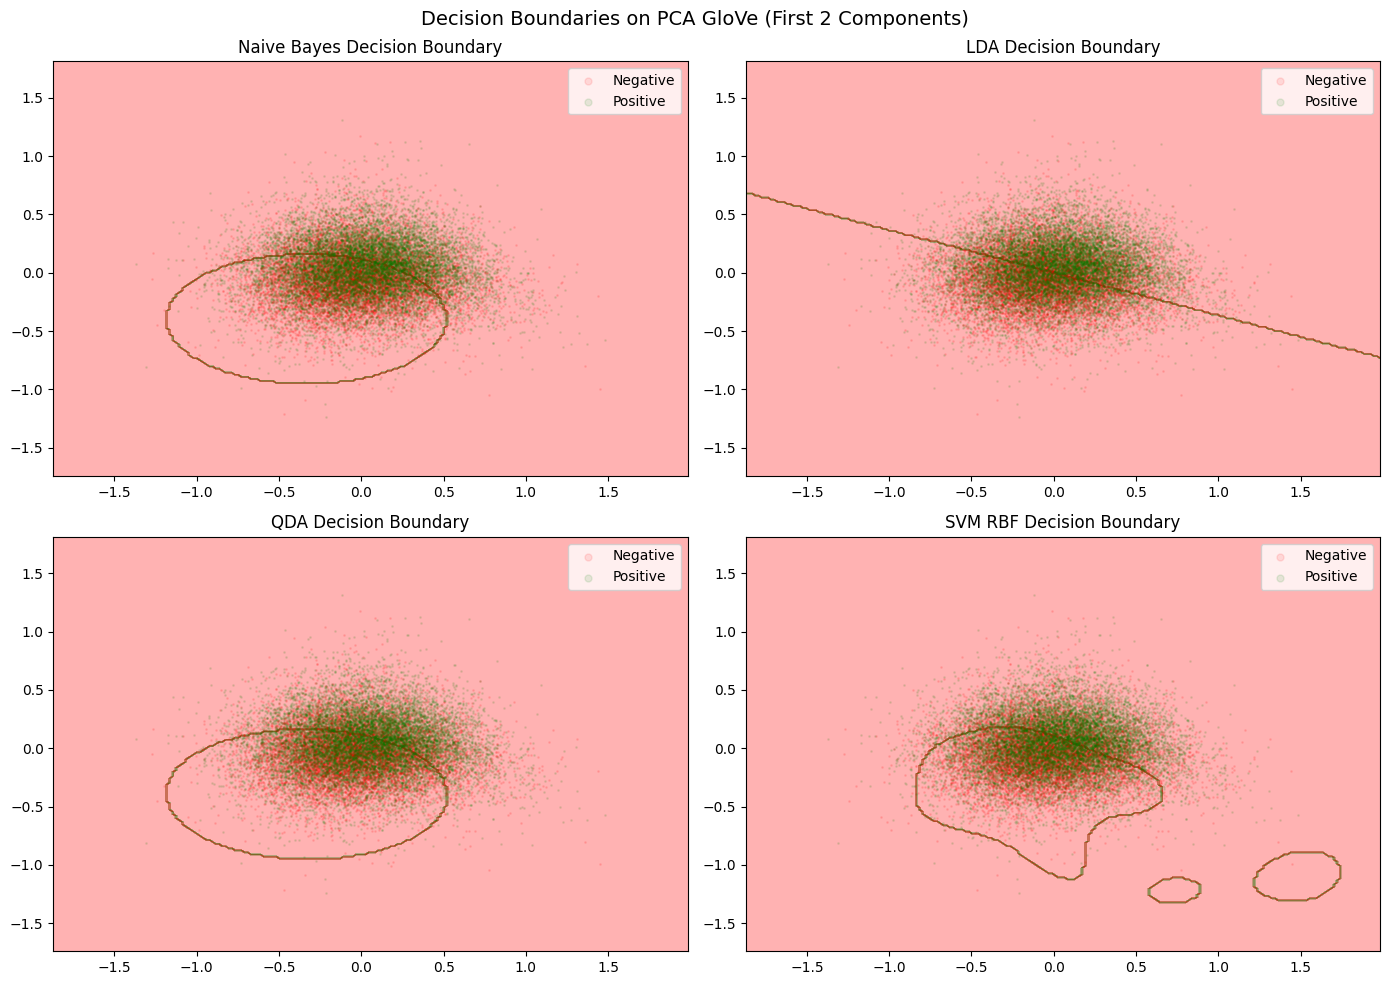

Decision boundary plot saved!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
X_train_2d = X_train_pca[:, :2]
X_test_2d = X_test_pca[:, :2]
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))
models = {
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SVM RBF": SVC(kernel="rbf", random_state=42)
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, (name, model) in enumerate(models.items()):
    # Train on 2D data
    model.fit(X_train_2d, y_train)
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[idx].contourf(xx, yy, Z, alpha=0.3, colors=["red", "green"])
    axes[idx].scatter(X_train_2d[y_train==0, 0],
                      X_train_2d[y_train==0, 1],
                      c="red", alpha=0.1, s=1, label="Negative")
    axes[idx].scatter(X_train_2d[y_train==1, 0],
                      X_train_2d[y_train==1, 1],
                      c="green", alpha=0.1, s=1, label="Positive")
    axes[idx].set_title(f"{name} Decision Boundary")
    axes[idx].legend(markerscale=5)
    plt.suptitle("Decision Boundaries on PCA GloVe (First 2 Components)", fontsize=14)
plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Decision boundary plot saved!")


In [20]:
import pandas as pd
import numpy as np
from groq import Groq
import time
from sklearn.metrics import f1_score
test_df = pd.read_csv("test_clean.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

sample_size = 200
test_sample = test_df.sample(n=sample_size, random_state=42)
y_sample = y_test[test_sample.index].reset_index(drop=True)
test_sample = test_sample.reset_index(drop=True)

print(f"Sample size: {len(test_sample)}")
print(f"Negative: {(y_sample==0).sum()}")
print(f"Positive: {(y_sample==1).sum()}")

Sample size: 200
Negative: 105
Positive: 95


In [ ]:

client = Groq(api_key="GROC_API_KEY")
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "user", "content": "Say hello in one word"}
    ]
)
print(response.choices[0].message.content)


Hello


In [25]:
def classify_sentiment(review):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "user",
                "content": f"Classify the sentiment of the following movie review as exactly 'positive' or 'negative'. Reply with only one word.\n\nReview: {review}"
            }
        ],
        max_tokens=5
    )
    result = response.choices[0].message.content.strip().lower()
    if "positive" in result:
        return 1
    else:
        return 0

predictions = []
start = time.time()

for i, review in enumerate(test_sample["filtered_text"]):
    pred = classify_sentiment(review)
    predictions.append(pred)
    if (i+1) % 20 == 0:
        print(f"Done: {i+1}/200")

end = time.time()


f1 = f1_score(y_sample, predictions)
total_time = end - start
infer_time = (total_time / 200) * 1000

print(f"\nDone!")
print(f"LLM F1 Score: {f1:.4f}")
print(f"Total time: {total_time:.2f} seconds")
print(f"Inference per review: {infer_time:.2f} ms")

Done: 20/200
Done: 40/200
Done: 60/200
Done: 80/200
Done: 100/200
Done: 120/200
Done: 140/200
Done: 160/200
Done: 180/200
Done: 200/200

Done!
LLM F1 Score: 0.8744
Total time: 398.87 seconds
Inference per review: 1994.33 ms


In [26]:
llm_results = {
    "Model": "Llama 3.1 8B (zero-shot)",
    "F1 Score": round(f1, 4),
    "Inference (ms)": round(infer_time, 2),
    "Total Time (s)": round(total_time, 2)
}
print(llm_results)

import json
with open("llm_results.json", "w") as f:
    json.dump(llm_results, f)
print("LLM results saved!")

{'Model': 'Llama 3.1 8B (zero-shot)', 'F1 Score': 0.8744, 'Inference (ms)': 1994.33, 'Total Time (s)': 398.87}
LLM results saved!
